# Assignment 3

Name: Arthur Yang  
Email: yarthur@umich.edu

Link to Github Repo: https://github.com/ArthurYang8/SIADS-521-Assignment-3

Link to Dashboard: https://siads-521-assignment-3-gq4t3vtrzubcg9te7og9hh.streamlit.app/

Link to Video: https://drive.google.com/file/d/1UHQIW8tzA_pAh3Ybba8KyyvJKW_gXJdO/view?usp=sharing

Framework Overview:

**Streamlit**: An open-source Python framework which converts Python scripts into interactive web applications without implementing HTML / JS scripts.

**Plotly Express** A delcarative charting library which produces responsive, WebGL / SVG-rendered figures natively from pandas Dataframes.

In [1]:
%pip install pandas numpy streamlit plotly --target=./local_packages

  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached streamlit-1.59.2-py3-none-any.whl.metadata (9.6 kB)
  Using cached plotly-6.9.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached altair-6.2.2-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.1.4-py3-none-any.whl.metadata (5.5 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.52-py3-none-any.whl.metadata (14 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pydeck-0.9.3-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached pro

Starlette is a web framework for Python in which Streamlit is built on. It powers the underlying web server which sends charts and controls to the browser.

In [2]:
!pip install "numpy<2" --target=./local_packages --upgrade
!pip install starlette --target=./local_packages

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached anyio-4.14.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
Using cached starlette-1.3.1-py3-none-any.whl (73 kB)
Using cached anyio-4.14.2-py3-none-any.whl (125 kB)
Using cached idna-3.18-py3-none-any.whl (65 kB)
Using cached typing_extensions-4.16.0-py3-none-any.whl (45 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [starlette]/4 [anyio]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nbgrader 0.9.5 requires notebook<8,>=7.2.0, but you have notebook 6.5.7 whi

**Framework Evaluation and Trade-Offs**

Declarative vs. Procedural: Plotly Express operatives declaratively since you can specify what data to map to visual properties while Streamlit handles the app layout procedurally (executing top to bottom sequentially upon user interaction)

Plotly Express integrates well with Jupyter Notebooks with the .show() method, making it good for prototyping and testing figures before integrating them into Streamlit web apps with st.plotly_chart().

Selection Justification: Unlike static plotting libraries like Matplotlib or seaborn, Plotly + Streamlit provides live responsiveness and built-in hover tooltips, as well as good cloud deployment.

In [3]:
import sys
sys.path.insert(0, './local_packages') #run once

import numpy as np
import pandas as pd
import plotly.express as px
import streamlit as st
import ipywidgets as widgets

**Dataset Overview**

This analysis utilizes the 2025 Fantasy Football Statistics sourced from the Fantasy Footballers website, with the PPR (Points Per Reception) 4PT QB scoring system: 

[2025 Fantasy Football Stats](https://www.thefantasyfootballers.com/2025-fantasy-football-stats/#:~:text=2025%20Fantasy%20Football%20Stats%20%2D%20Total.%20Total,Player.%20POS.%20PTS.%20PTS%2FG.%20GP.%20CMP.%20YDS.)

**Data Cleaning**

Data cleaning was relatively simple since this dataset was already in a csv file which was straight forward to read in with pd.read_csv(), so we only had to do a few simple steps to have the data be fully ready for visualization:

1. Column Renaming - The raw stats columns did come with some duplicate names (YDS, YDS.1, YDS.2) since they represent different types of yards from scrimmage (Passing, Rushing, Receiving). So I explicitly renamed these to make them less ambiguous and match the raw data from the source (Passing Yards, Rushing Yards, Receiving Yards).

2. Calculated Columns - Some new columns that I added to the dataset was the relative rank per position based on total points. So for example, all Tight Ends were grouped together and were ranked on total points. Thus, multiple players can have a rank of 1 (Josh Allen and Trey McBride for instance)

3. Row Filtering - For many of the visuals, I only took the top 30 or 50 players of a certain position to only take players that are likely to make impact in a Fantasy Football Tournament, and also reduces noise especially from players who are active but not typically starting. (they typically do not score many points)

In [4]:
df = pd.read_csv('2025 Fantasy Football Stats - Fantasy Footballers Podcast.csv')

In [5]:
df.head()

,Name,Team,POS,PTS,PTS/G,GP,CMP,YDS,TD,INT,ATT,YDS.1,TD.1,FUM,TGT,REC,YDS.2,TD.2
0,Christian McCaffrey,SF,RB,416.6,24.5,17,0,0,0,0,311,1202,10,0,129,102,924,7
1,Puka Nacua,LAR,WR,375.0,23.4,16,0,0,0,0,10,105,1,1,166,129,1715,10
2,Bijan Robinson,ATL,RB,370.8,21.8,17,0,0,0,0,287,1478,7,3,103,79,820,4
3,Jahmyr Gibbs,DET,RB,366.9,21.6,17,0,0,0,0,243,1223,13,1,94,77,616,5
4,Josh Allen,BUF,QB,364.6,21.4,17,319,3668,25,10,112,579,14,3,0,0,0,0


In [6]:
rename_columns = {
    'CMP': 'Pass Completions',
    'YDS': 'Passing Yards',
    'TD': 'Passing TDs',
    'INT': 'Interceptions',

    'ATT': 'Rushing Attempts',
    'YDS.1': 'Rushing Yards',
    'TD.1': 'Rushing TDs',
    'FUM': 'Fumbles',

    'TGT': 'Targets',
    'REC': 'Receptions',
    'YDS.2': 'Receiving Yards',
    'TD.2': 'Receiving TDs'
}

df = df.rename(columns = rename_columns)
df.head()

,Name,Team,POS,PTS,PTS/G,GP,Pass Completions,Passing Yards,Passing TDs,Interceptions,Rushing Attempts,Rushing Yards,Rushing TDs,Fumbles,Targets,Receptions,Receiving Yards,Receiving TDs
0,Christian McCaffrey,SF,RB,416.6,24.5,17,0,0,0,0,311,1202,10,0,129,102,924,7
1,Puka Nacua,LAR,WR,375.0,23.4,16,0,0,0,0,10,105,1,1,166,129,1715,10
2,Bijan Robinson,ATL,RB,370.8,21.8,17,0,0,0,0,287,1478,7,3,103,79,820,4
3,Jahmyr Gibbs,DET,RB,366.9,21.6,17,0,0,0,0,243,1223,13,1,94,77,616,5
4,Josh Allen,BUF,QB,364.6,21.4,17,319,3668,25,10,112,579,14,3,0,0,0,0


## Chart 1: Value Scarcity Curve (Categorical Bar Chart)

Visualization Type: Categorical Bar Chart with Aggregated Mean Values

Variables Plotted: 
  - X-axis: Performance Tier (Top 5, Elite, Solid, Depth, Waiver Wire) which is based on the column "PositionRank".  
  - Y-axis: Average Total Fantasy Points (PTS)
  - Color Scale: Based on the performance tier

Purpose: This visualization measures positional drop-off severity and scarcity. By grouping players into standardized rank buckets relative to their position (PositionRank), the chart calculates the average point output produced at each tier.

Insights & Intepretation: This allows fantasy football managers to visually compare the steepness of the point drop-off across positions. For example, quarterbacks (and surprisingly Tight Ends) at tier 3 have a point drop off less than 100 points compared to the quarterbacks at tier 1, encouraging fantasy managers to hold off on that position for more valuable players.  

On the other hand, positions like running back and wide receiver are more valuable and have a much steeper point drop off at tier 3 and beyond, making them more scarce as the fantasy draft progresses.

In [7]:
# Position Rank Column

df['PositionRank'] = df.groupby('POS')['PTS'].rank(ascending = False, method = 'first')

def assign_tier(rank):
    if rank <= 5:
        return '1: Top 5 (Ranks 1-5)'
    elif rank <= 10:
        return '2: Elite (Ranks 6-10)'
    elif rank <= 15:
        return '3: Solid (Ranks 11-15)'
    elif rank <= 20:
        return '4: Depth (Ranks 16-20)'
    else:
        return '5: Waiver Wire (Ranks 21+)'

df['Tier'] = df['PositionRank'].apply(assign_tier)
# df[df['Name'] == 'Trey McBride'] - Test to see if the position rank is working

pos_dropdown = widgets.Dropdown(
    options=['QB', 'RB', 'WR', 'TE'], 
    value='QB', 
    description='Position:'
)

@widgets.interact(selected_position=pos_dropdown)
def plot_value_scarcity(selected_position):
    filtered_df = df[df['POS'] == selected_position]
    avg_tier_points = filtered_df.groupby('Tier', as_index=False)['PTS'].mean().sort_values('Tier')

    fig_tier = px.bar(
        avg_tier_points,
        x='Tier',
        y='PTS',
        text_auto='.1f',
        labels={'PTS': 'Avg Points', 'Tier': 'Performance Tier'},
        title=f'Average Total Points by Tier ({selected_position})',
        color='Tier',
        color_discrete_sequence=px.colors.sequential.OrRd_r,
        width=950,
        height=450
    )
    fig_tier.update_layout(showlegend=False)
    fig_tier.show()

interactive(children=(Dropdown(description='Position:', options=('QB', 'RB', 'WR', 'TE'), value='QB'), Output(…

## Chart 2: Top 50 Running Back Profiles (Scatter Plot with Quadrants)

Visualization Type: Multivariable Scatter Plot with Quadrant Medians

Variables Plotted: 
  - X-axis: Total Rushing Yards (Rushing Yards)
  - Y-axis: Total Receiving Yards (Receiving Yards)
  - Marker Size: # of Receptions (Receptions)
  - Marker Color: Total Fantasy Points (PTS)
  - Quadrant Lines: Red lines placed at the median values for Rushing Yards and Receiving Yards

Purpose: This visualization evaluates player versatility and role archetypes among the top 50 running backs by mapping ground production against pass-catching production.

Insights & Intepretation: Fantasy managers with this chart can look up certain players to see which of the quadrants they fall in and thus, gain or meddle confidence in a player for their fantasy team. In general, running backs that are in the upper right of the graph are the best at producing fantasy points.

However, there is some nuance as many managers (such as myself) want running backs who are capable of catching passes to increase opportunities for scoring points more consistently throughout the season. Thus, the coloring scale and size of the dots gives this information visually to give a more complete profile of a running back.

In [8]:
# Running back quadrants

rb_test = df[(df['POS'] == 'RB') & (df['PTS'] > 0)].copy()
rb_test = rb_test.sort_values(by = 'PTS', ascending = False).head(50)

mid_x = rb_test['Rushing Yards'].median()
mid_y = rb_test['Receiving Yards'].median()

fig_test = px.scatter(
    rb_test,
    x='Rushing Yards',
    y='Receiving Yards',
    color='PTS',
    size='Receptions',  # Bigger dot = catches more balls
    hover_name='Name',
    title="Top 50 Running Back Profiles: Rushing vs. Receiving Volume",
    labels={
        'Rushing Yards': 'Total Rushing Yards',
        'Receiving Yards': 'Total Receiving Yards',
        'PTS': 'Total Fantasy Points'
    },
    color_continuous_scale=px.colors.sequential.Viridis,
    width=950,
    height=650
)

fig_test.add_vline(x=mid_x, line_dash="dash", line_color="red", annotation_text=" Rushing Baseline")
fig_test.add_hline(y=mid_y, line_dash="dash", line_color="red", annotation_text=" Receiving Baseline")

fig_test.update_layout(hovermode='closest')
fig_test.show()

**Chart 3: Top 50 Wide Receiver Distribution (Grouped Histogram)**

Visualization Type: Binned Frequency Histogram and a Data Table

Variables Plotted:
  - X-axis: Total Fantasy Points (PTS)
  - Y-axis: Player Count
  - Categorical Groupings (Color): Route Archetype (Explosive / Deep Threat, Balanced, Short Route / Checkdown) derived from Yards per Reception.

Note: The Route Archetype is determined by the percentile of the top 50 wide receivers in total fantasy points in terms of Yards Per Reception (Total Yards / Total Receptions). Specifically, WRs in the 33rd percentile or lower are grouped as Short Route / Checkdown receivers, WRs under the 66th percentile are grouped as balanced receivers, and the remaining are grouped as Explosive Deep Threats.

Purpose: This chart examines the point distribution spread across wide receivers to see if deep-threat big-play receivers or high-volume receivers produce higher fantasy point floors and ceilings.

Insights & Intepretation: By thresholding wide receivers into the 33rd and 66th percentiles based on Yards per Reception, this shows whether Explosive players skew towards high-variance outcomes compared to high-volume targets.

Interestingly enough, while it does seem to be true that explosive receivers tend to have right-skewed in terms of total fantasy points, check down receivers also seem to follow a similar (albeit not as strong) trend. This may be due to the fact that these checkdown receivers may have games where if the volume ever decreases, their production plummets.

In [9]:
# Wide receiver archetypes Histogram

wr_df = df[df['POS'] == 'WR'].copy()
wr_df = wr_df.sort_values(by='PTS', ascending=False).head(50)

wr_df['YPR'] = wr_df['Receiving Yards'] / wr_df['Receptions']

p33 = wr_df['YPR'].quantile(0.33)
p66 = wr_df['YPR'].quantile(0.66)

def categorize_wr(ypr):
    if ypr > p66:   return 'Explosive (Deep Threat)'
    elif ypr > p33: return 'Average (Balanced)'
    else:           return 'Short Route / Checkdown'

wr_df['Archetype'] = wr_df['YPR'].apply(categorize_wr)

fig_wr_hist = px.histogram(
    wr_df,
    x='PTS',
    color='Archetype',
    nbins=15,
    title="Point Distribution Spread by WR Archetype",
    labels={'PTS': 'Total Fantasy Points', 'count': 'Number of Players'},
    color_discrete_map={
        'Explosive (Deep Threat)': '#FF4B4B',
        'Average (Balanced)': '#FFA500',
        'Short Route / Checkdown': '#001F3F'
    }
)

fig_wr_hist.show()
#st.plotly_chart(fig_wr_hist, use_container_width=True)
display(wr_df[['Name', 'Archetype', 'YPR', 'PTS']].sort_values(by=['Archetype', 'PTS'], ascending=[True, False]).head(5))

,Name,Archetype,YPR,PTS
1,Puka Nacua,Average (Balanced),13.294574,375.0
30,Zay Flowers,Average (Balanced),14.081395,243.3
42,Davante Adams,Average (Balanced),13.150000,222.9
44,Michael Wilson,Average (Balanced),12.897436,220.6
45,A.J. Brown,Average (Balanced),12.858974,220.3


Chart 4: Quarterback Efficiency Line Plot  
Visualization Type: Line Plot with Data Markers  

Variables Plotted:  

  - X-axis: Total Rushing Yards (Rushing Yards)
  - Y-axis: Total Fantasy Points (PTS)
  - Hover metadata: Player (QB) Name, Total Rushing Yards, Total Passing Yards, and Total Fantasy Points.

Purpose: This visual illustrates passing volume against total fantasy points to show the strength of the trend between these two variables, while hiding the impact of the rushing yards for mobile quarterbacks.

Insights & Intepretation: While traditional pocket passers (i.e. Jared Goff) display a generally linera relationship between passing yards and total fantasy points, mobile QBs (Jalen Hurts) create sharp upwards spikes on the line. These points show how much impact a mobile QB has on their total fantasy production compared to just the passing yards.

In [10]:
qb_df = df[df['POS'] == 'QB'].copy()
qb_df = qb_df.sort_values(by='Passing Yards', ascending=False).head(30)

fig_qb_line = px.line(
    qb_df,
    x='Passing Yards',
    y='PTS',
    hover_name='Name',
    # hover_data = {'Rushing Yards': True},
    title="Quarterback Efficiency: Passing Yards vs. Total Points",
    labels={'Passing Yards': 'Total Passing Yards', 'Rushing Yards': 'Total Rushing Yards', 'PTS': 'Total Fantasy Points'},
    markers=True,  # Adds dots on the line for each player
    width=950,
    height=450
)
# Style the line to look clean and custom
fig_qb_line.update_traces(line=dict(color='#4A6FA5', width=3), marker=dict(size=8))
fig_qb_line.show()

In [11]:
# Page setup and Titles

st.set_page_config(layout="wide")

st.title('2025 Fantasy Football Analytics Dashboard')
st.markdown('Explore positional value scarcity, efficiency metrics, and distribution models.')

# Data Pulling and Cleaning

data_url = "https://raw.githubusercontent.com/ArthurYang8/SIADS-521-Assignment-3/main/2025%20Fantasy%20Football%20Stats%20-%20Fantasy%20Footballers%20Podcast.csv"
df = pd.read_csv(data_url)

rename_columns = {
    'CMP': 'Pass Completions',
    'YDS': 'Passing Yards',
    'TD': 'Passing TDs',
    'INT': 'Interceptions',
    'ATT': 'Rushing Attempts',
    'YDS.1': 'Rushing Yards',
    'TD.1': 'Rushing TDs',
    'FUM': 'Fumbles',
    'TGT': 'Targets',
    'REC': 'Receptions',
    'YDS.2': 'Receiving Yards',
    'TD.2': 'Receiving TDs'
}

df = df.rename(columns = rename_columns)
df['PositionRank'] = df.groupby('POS')['PTS'].rank(ascending = False, method = 'first')

def assign_tier(rank):
    if rank <= 5:
        return '1: Top 5 (Ranks 1-5)'
    elif rank <= 10:
        return '2: Elite (Ranks 6-10)'
    elif rank <= 15:
        return '3: Solid (Ranks 11-15)'
    elif rank <= 20:
        return '4: Depth (Ranks 16-20)'
    else:
        return '5: Waiver Wire (Ranks 21+)'
df['Tier'] = df['PositionRank'].apply(assign_tier)

# Isolate top 50 RBs 
rb_df = df[df['POS'] == 'RB'].copy()
rb_df = rb_df.sort_values(by='PTS', ascending=False).head(50)

mid_x = rb_df['Rushing Yards'].median()
mid_y = rb_df['Receiving Yards'].median()

rb_list = sorted(rb_df['Name'].tolist())

# Isolate Top 50 WRs
wr_df = df[df['POS'] == 'WR'].copy()
wr_df = wr_df.sort_values(by='PTS', ascending=False).head(50)
wr_df['YPR'] = wr_df['Receiving Yards'] / wr_df['Receptions']

p33 = wr_df['YPR'].quantile(0.33)
p66 = wr_df['YPR'].quantile(0.66)

def categorize_wr(ypr):
    if ypr > p66:   return 'Explosive (Deep Threat)'
    elif ypr > p33: return 'Average (Balanced)'
    else:           return 'Short Route / Checkdown'
wr_df['Archetype'] = wr_df['YPR'].apply(categorize_wr)

# Isolate Top 30 QBs
qb_df = df[df['POS'] == 'QB'].copy()
qb_df = qb_df.sort_values(by='Passing Yards', ascending=False).head(30)

# Interactive Controls

position_dropdown = widgets.Dropdown(options = ['QB', 'RB', 'WR', 'TE'], value = 'QB', description = 'Position:')
player_search = widgets.Combobox(options=rb_list, value='', placeholder='Type player name...', description='Find RB:', ensure_option=False)
wr_dropdown = widgets.Dropdown(options=['All Archetypes', 'Explosive (Deep Threat)', 'Average (Balanced)', 'Short Route / Checkdown'], value='All Archetypes', description='WR Type:')

@widgets.interact(selected_position = position_dropdown, search_name = player_search, selected_archetype = wr_dropdown)
def update_dashboard(selected_position, search_name, selected_archetype):
    # Chart 1 - Value Scarcity Curve
    filtered_df = df[df['POS'] == selected_position]
    avg_tier_points = filtered_df.groupby('Tier', as_index=False)['PTS'].mean().sort_values('Tier')

    fig_tier = px.bar(
        avg_tier_points,
        x='Tier',
        y='PTS',
        text_auto='.1f',
        labels={'PTS': 'Avg Points', 'Tier': 'Performance Tier'},
        title=f'Average Total Points Dropped by Tier ({selected_position})',
        color='Tier',
        color_discrete_sequence=px.colors.sequential.OrRd_r
    )
    fig_tier.update_layout(showlegend=False)
    fig_tier.show()

    # Chart 2 - RB Quadrants
    fig_scatter = px.scatter(
        rb_df,
        x='Rushing Yards',
        y='Receiving Yards',
        color='PTS',
        size='Receptions',
        hover_name='Name',
        title="Top 50 Running Back Profiles: Rushing vs. Receiving Yards",
        labels={
            'Rushing Yards': 'Total Rushing Yards',
            'Receiving Yards': 'Total Receiving Yards',
            'PTS': 'Total Fantasy Points'
        },
        color_continuous_scale=px.colors.sequential.Viridis,
        width=950,
        height=600
    )

    if search_name and search_name in rb_df['Name'].values: # make the RB of interest more apparent
        opacity_array = [1.0 if n == search_name else 0.15 for n in rb_df['Name']] # make the other RB's more transparent to dilute noise
    else:
        opacity_array = [0.85 for _ in rb_df['Name']] 
        
    fig_scatter.update_traces(
        marker=dict(opacity = opacity_array)
    )

    fig_scatter.add_vline(x=mid_x, line_dash="dash", line_color="red", annotation_text=" Rushing Median")
    fig_scatter.add_hline(y=mid_y, line_dash="dash", line_color="red", annotation_text=" Receiving Median")
    fig_scatter.update_layout(hovermode='closest')
    fig_scatter.show()

    # Chart 3 - WR Archetypes
    if selected_archetype != 'All Archetypes':
        filtered_wr = wr_df[wr_df['Archetype'] == selected_archetype]
    else:
        filtered_wr = wr_df

    fig_wr_hist = px.histogram(
        filtered_wr,
        x='PTS',
        color='Archetype',
        nbins=15,
        title=f"Top 50 Wide Receivers Point Distribution Spread: {selected_archetype}",
        labels={'PTS': 'Total Fantasy Points'},
        color_discrete_map={
            'Explosive (Deep Threat)': '#FFD166',
            'Average (Balanced)': '#06D6A0',
            'Short Route / Checkdown': '#118AB2'
        },
        width=950,
        height=450
    )
    fig_wr_hist.update_layout(yaxis_title="Number of Players")
    fig_wr_hist.show()
    
    # Clean list breakdown right beneath the isolated histogram
    with pd.option_context('display.max_rows', 10):
        display(filtered_wr[['Name', 'Archetype', 'YPR', 'PTS']].sort_values(by='PTS', ascending=False))

    # Chart 4 - QB Passing Yards Line Chart
    fig_qb_line = px.line(
        qb_df,
        x='Passing Yards',
        y='PTS',
        hover_name='Name',
        hover_data={'Rushing Yards': True},
        title="Quarterback Efficiency: Passing Yards vs. Total Points",
        labels={
            'Passing Yards': 'Total Passing Yards', 
            'Rushing Yards': 'Total Rushing Yards', 
            'PTS': 'Total Fantasy Points'
        },
        markers=True,
        width=950,
        height=450
    )
    fig_qb_line.update_traces(line=dict(color='#4A6FA5', width=3), marker=dict(size=8))
    fig_qb_line.show()


2026-07-20 04:45:56.794 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 04:45:56.795 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 04:45:56.987 WARNING streamlit.config: 
'server.enableXsrfProtection=true'.
As a result, 'server.enableCORS' is being overridden to 'true'.

More information:
In order to protect against CSRF attacks, we send a cookie with each request.
To do so, we must specify allowable origins, which places a restriction on
cross-origin resource sharing.

If cross origin resource sharing is required, please disable server.enableXsrfProtection.
            
2026-07-20 04:45:56.989 WARNING streamlit: 
  command:

    streamlit run /opt/python/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-07-20 

interactive(children=(Dropdown(description='Position:', options=('QB', 'RB', 'WR', 'TE'), value='QB'), Combobo…

## Debugging and Troubleshooting

**1. Non-breaking Space Encoding Errors in Markdown Links**

Problem: Unencoded space characters inside URL strings can break the HTTP request execution for pandas link parsing.

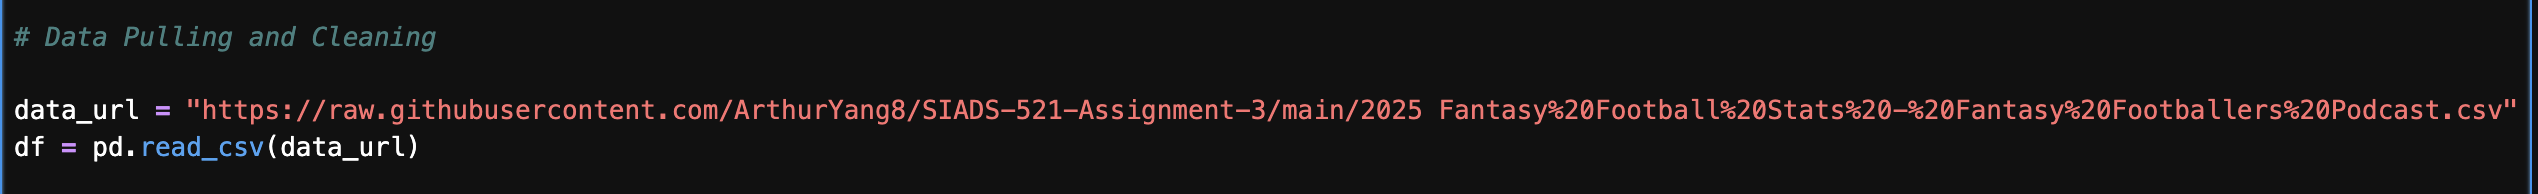

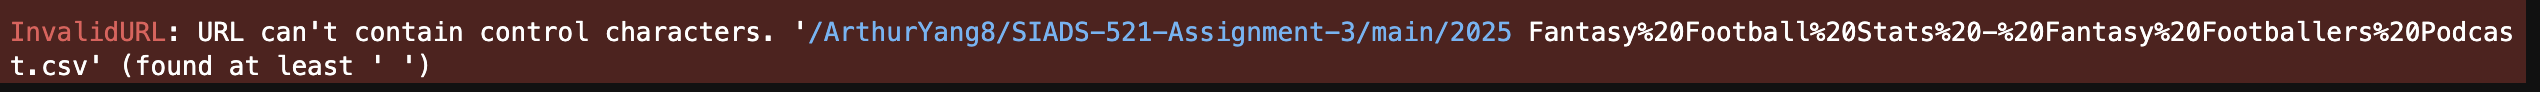

Solution: Ensure space characters within URL strings are explicitly encoded as "%20"
  
**2. Plotly Line Rendering and Vector Order**
  
Problem: The px.line connects data points sequentially based on the raw row index order of the input data frame. Since the dataframe was originally sorted descending by total fantasy points, plotting passing yards on the x-axis caused the line path to criss cross.  

<img src = attachment:7e47607f-0746-4585-9c54-62ac09beb439.png width = "600" height = "300">
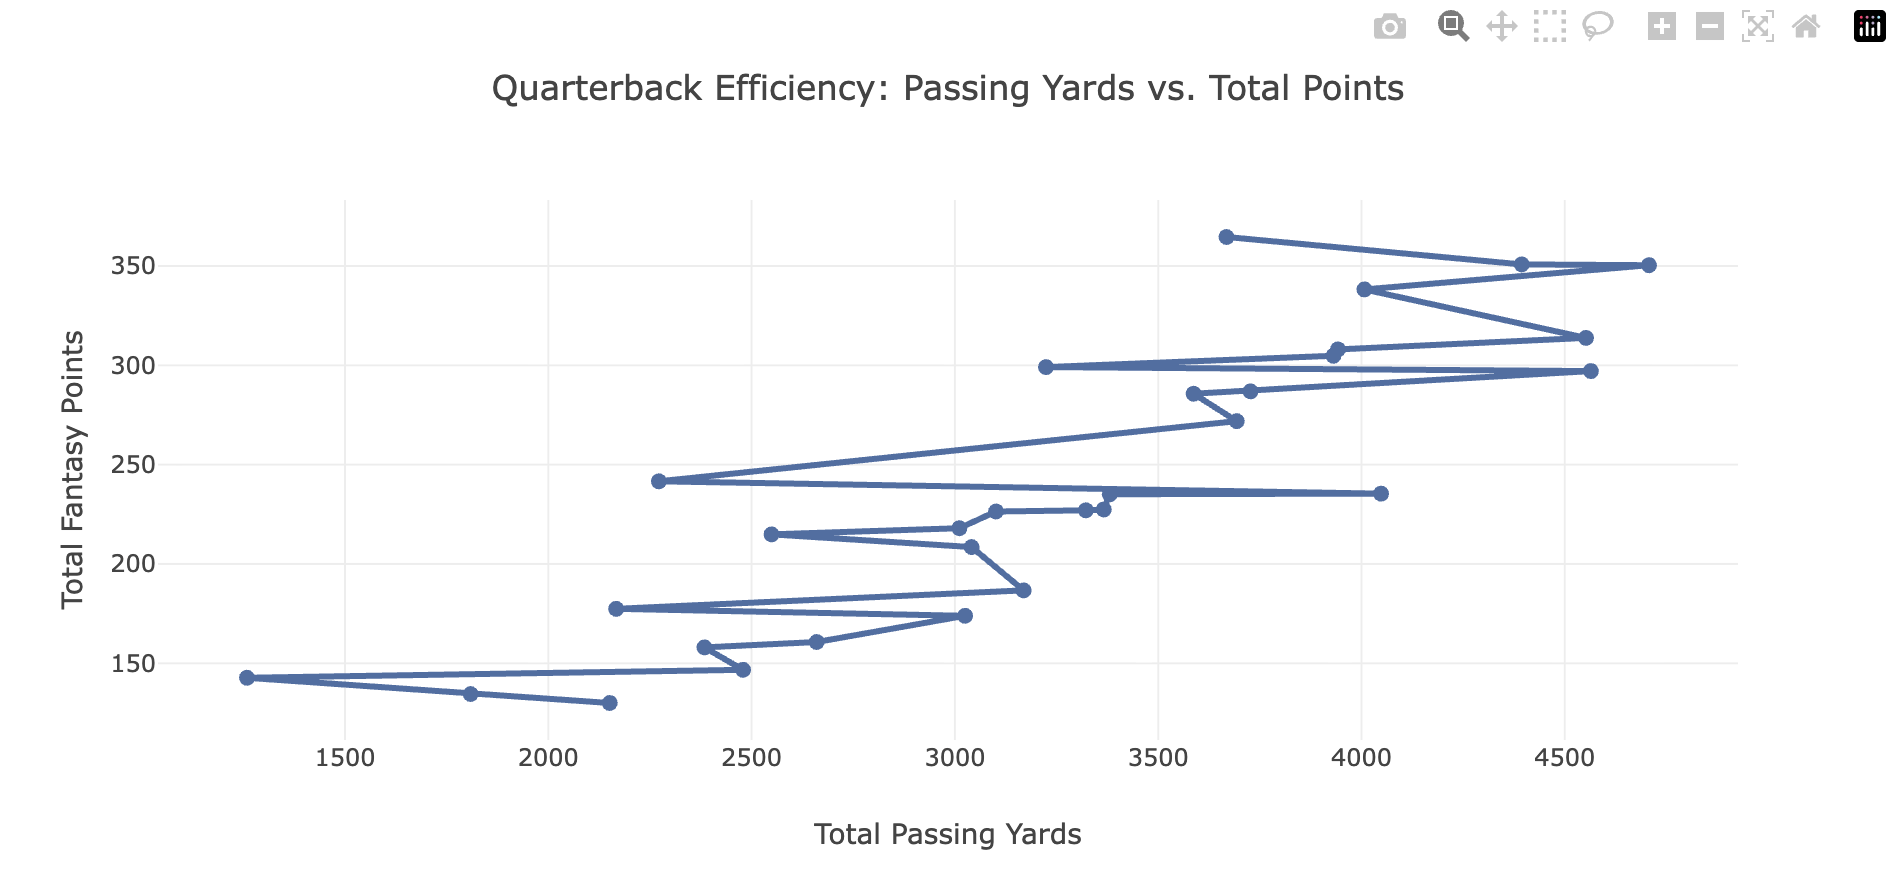

Solution: Sort the dataframe by the Passing Yards prior to rendering.
  
**3. Missing Tooltip Data in Plotly Hover Template**
  
Problem: Plotly Express defaults hover tooltips to only show the metrics explicitly mapped to the x and y axes. Context such as Rushing Yards is omitted from the tooltip by default, obscuring important details.

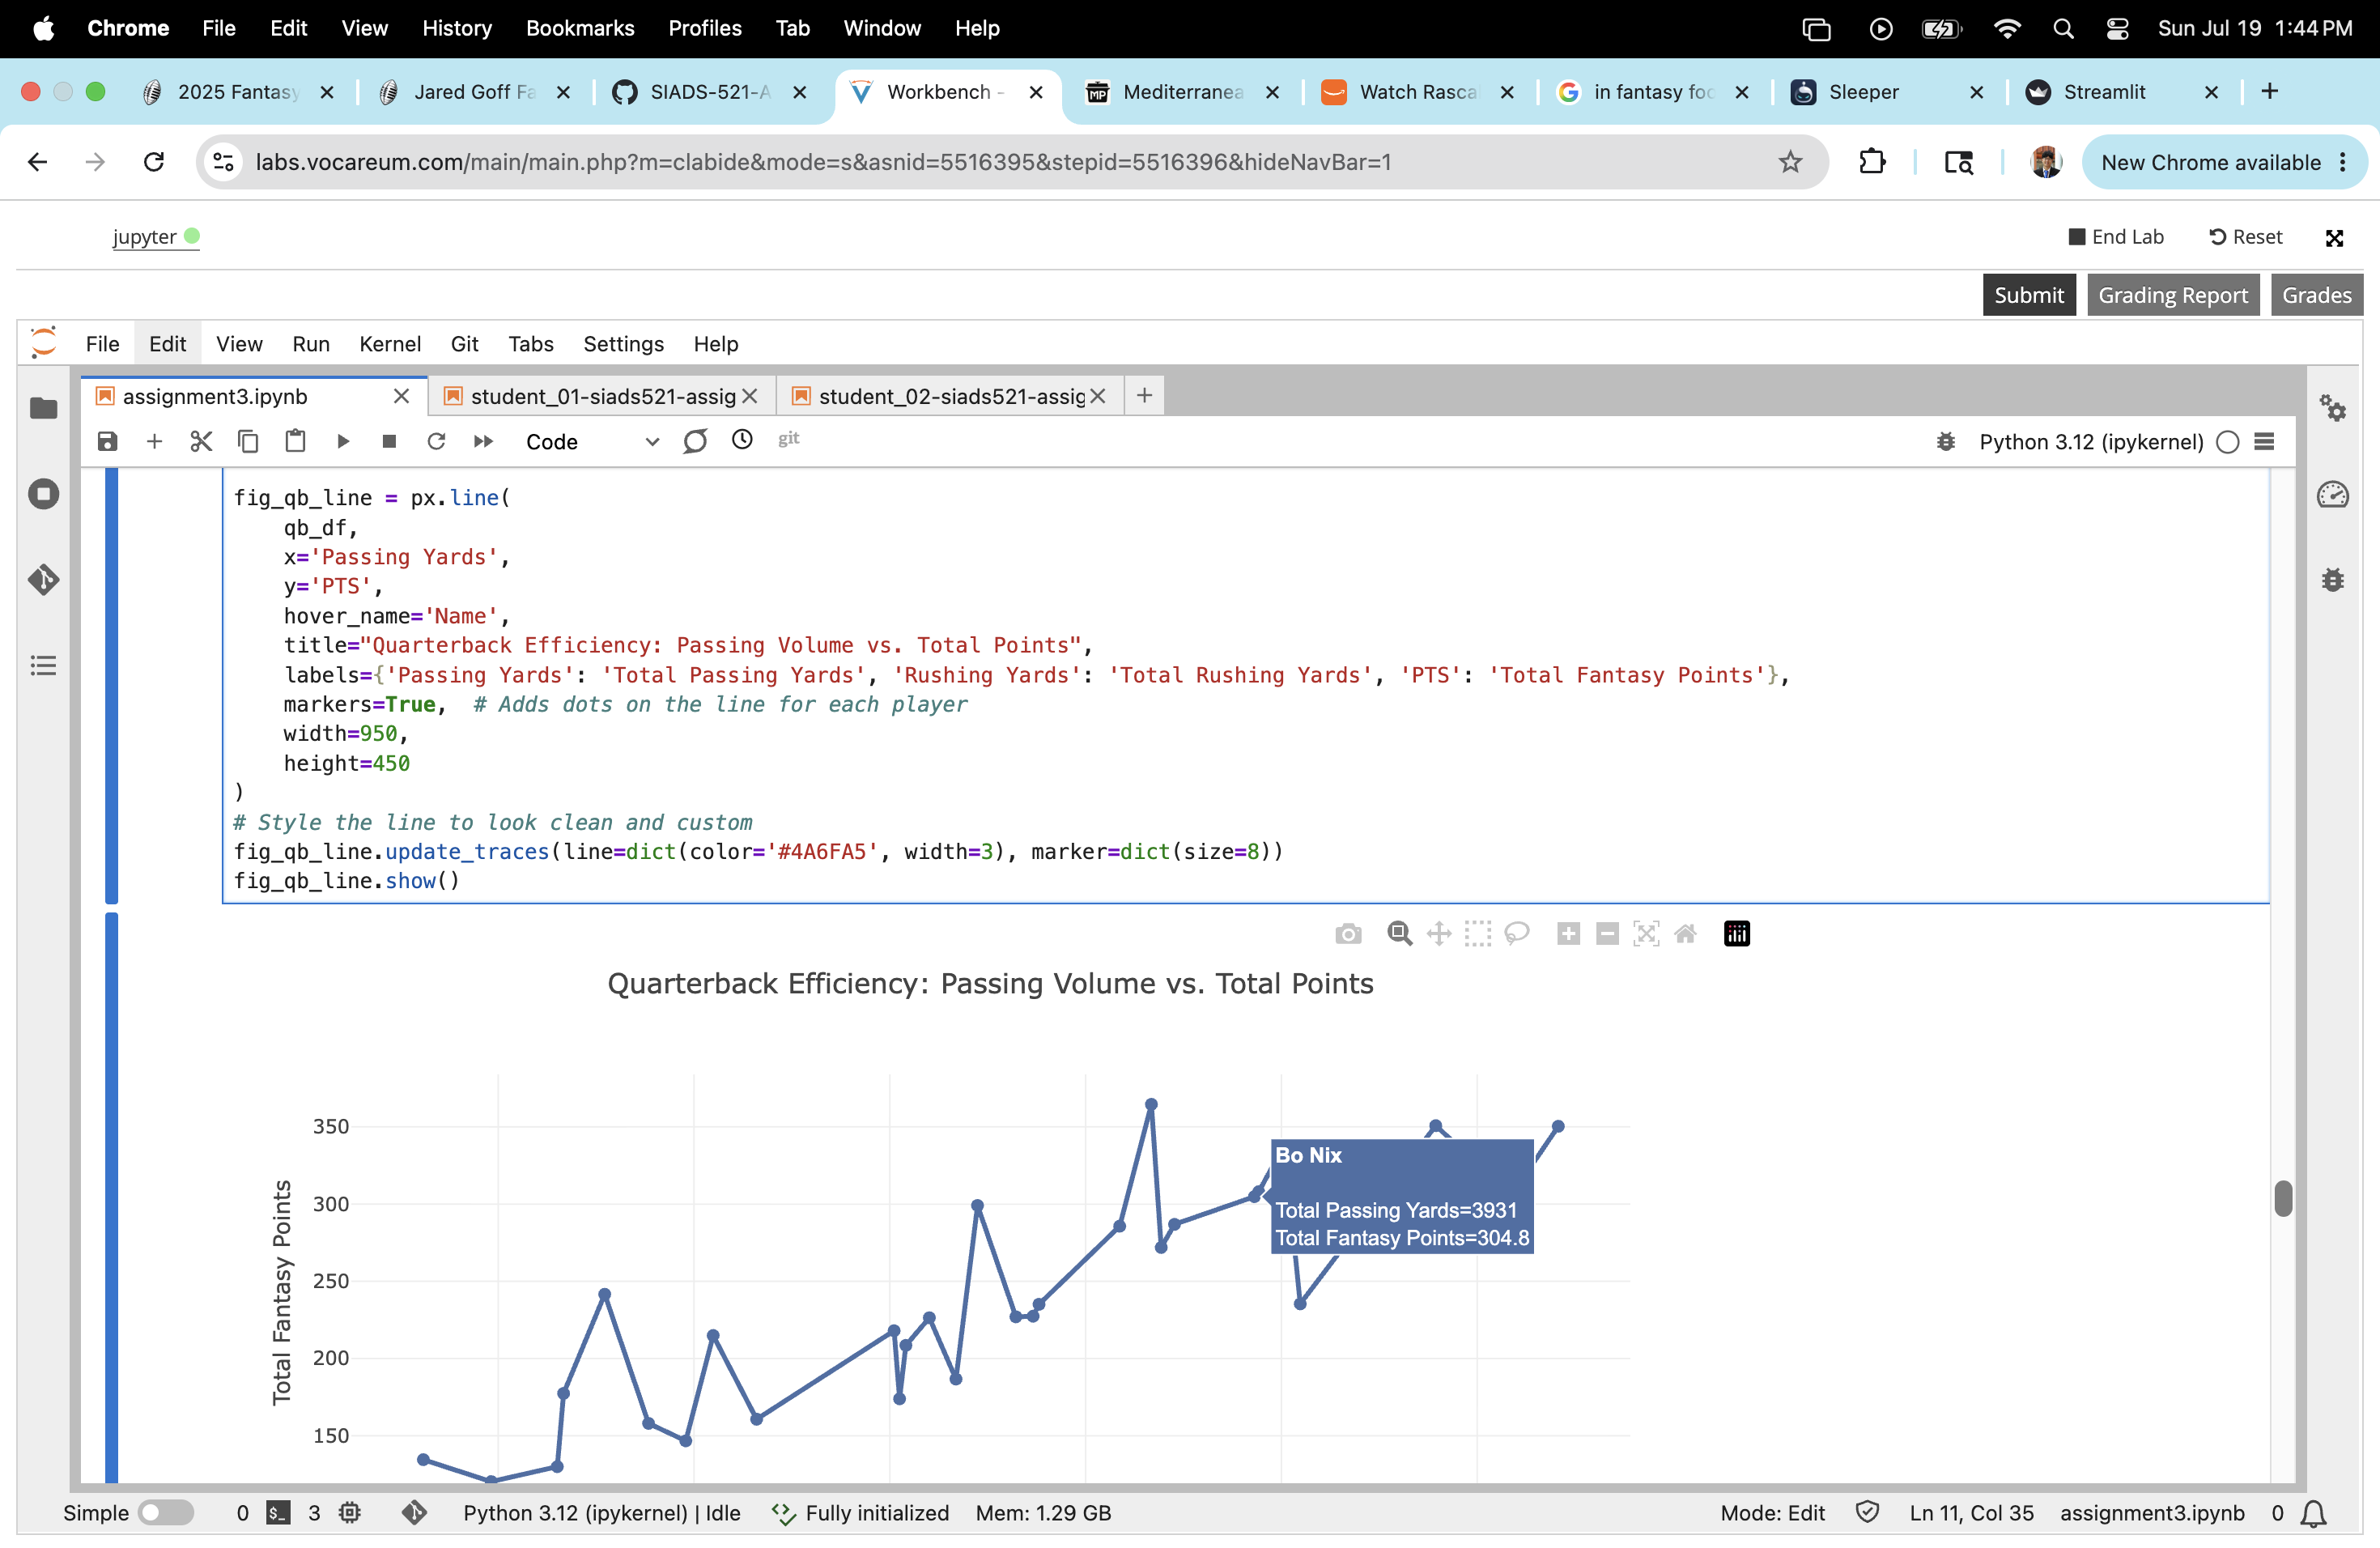

Solution: Use the hover_data parameter to explicitly pass in non-visual Dataframe columns into the interactive hover card.

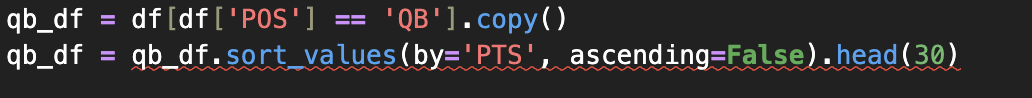

## Dashboard Deployment Instructions

The interactive dashboard is hosted publicly on **Streamlit Community Cloud** and requires no local setup or manual installation to view.

If you wish to run the Streamlit application on your local machine, follow these steps:

  1. Clone the repository - git clone https://github.com/ArthurYang8/SIADS-521-Assignment-3.git
cd SIADS-521-Assignment-3

  2. Install Required Dependencies: Ensure you have Python 3.9+ installed, then install the necessary libraries: pip install streamlit plotly pandas numpy

  3. Launch the streamlit app by executing the main application file: streamlit run app.py

The app was deployed by linking the SIADS-521-Assignment-3 GitHub repository directly to Streamlit Community Cloud. Streamlit automatically reads requirements.txt, builds the Python environment, and executes app.py on continuous integration pushes to main.